MATCHED FILTER DELAY
Single RRC filter delay: 32 samples
Total cascade delay: 64 samples
Detected symbols: 1000
BER at 10 dB: 0.0


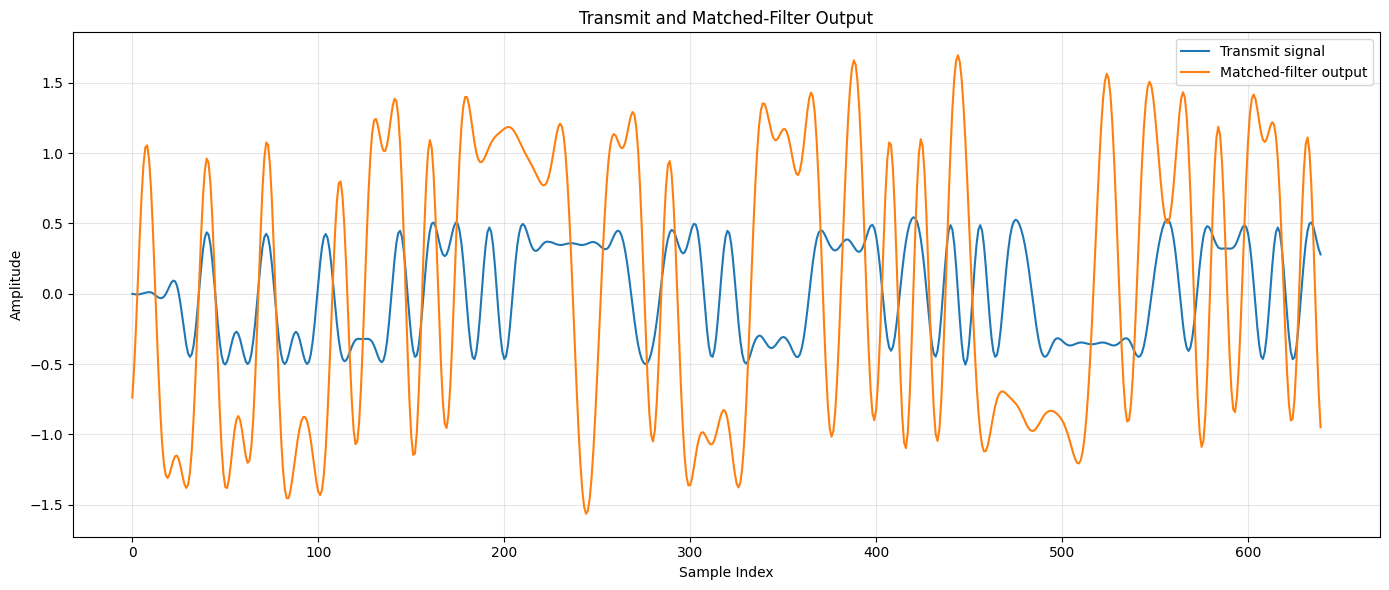

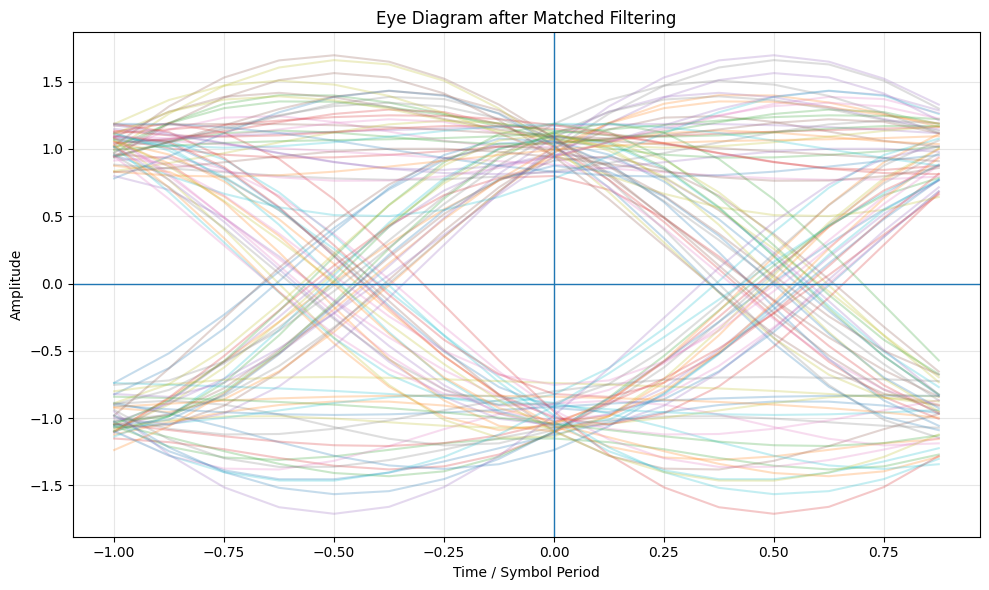

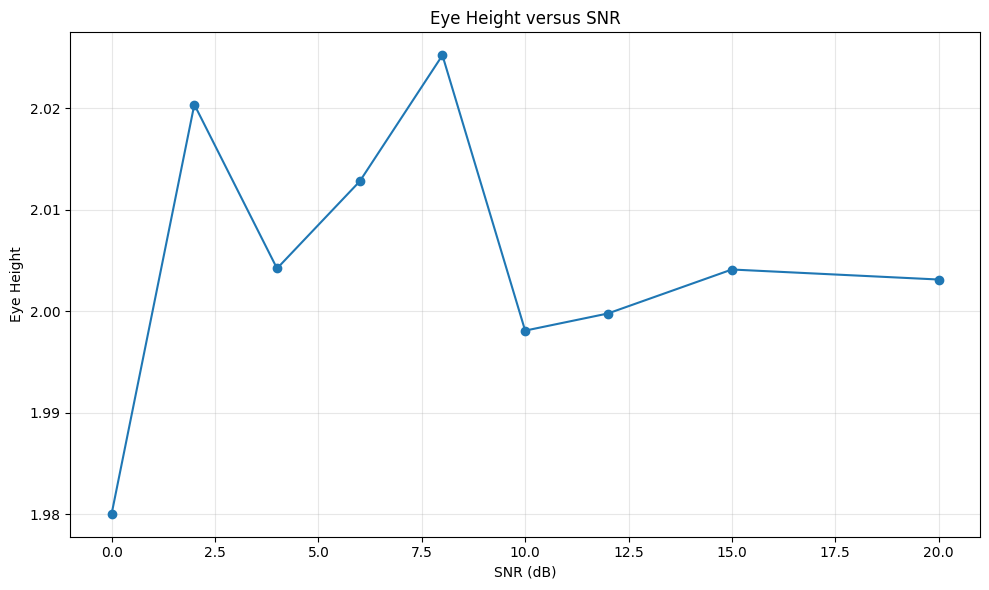

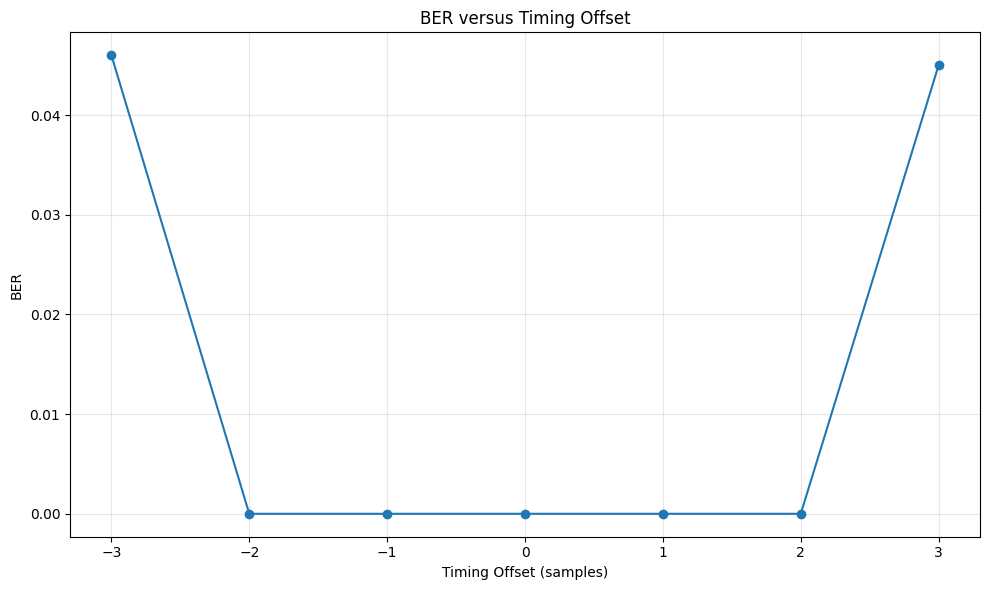


MULTIPATH ISI CHANNEL
Multipath channel: [1.  0.4 0.2]
BER with multipath ISI: 0.0


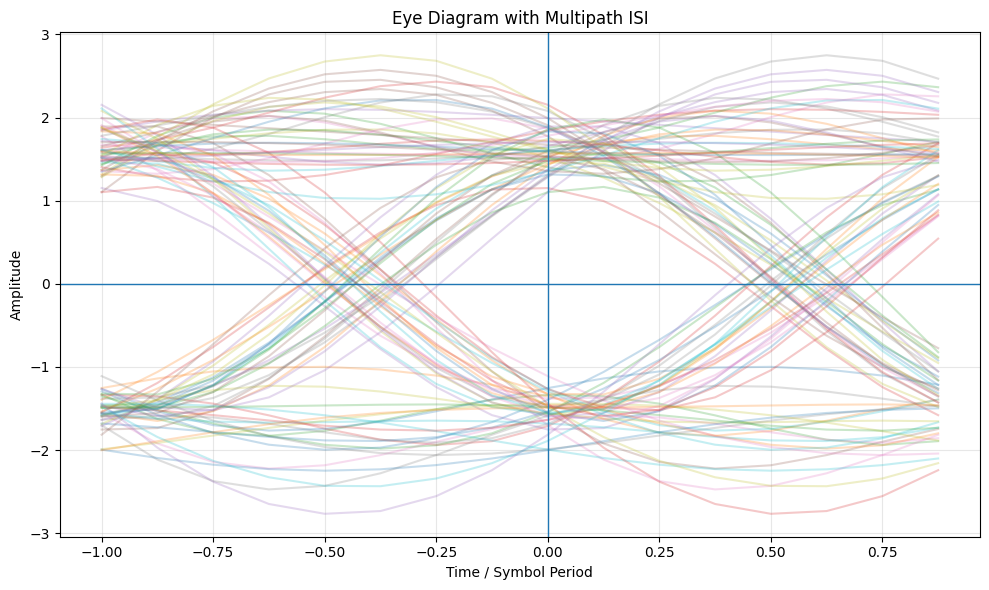

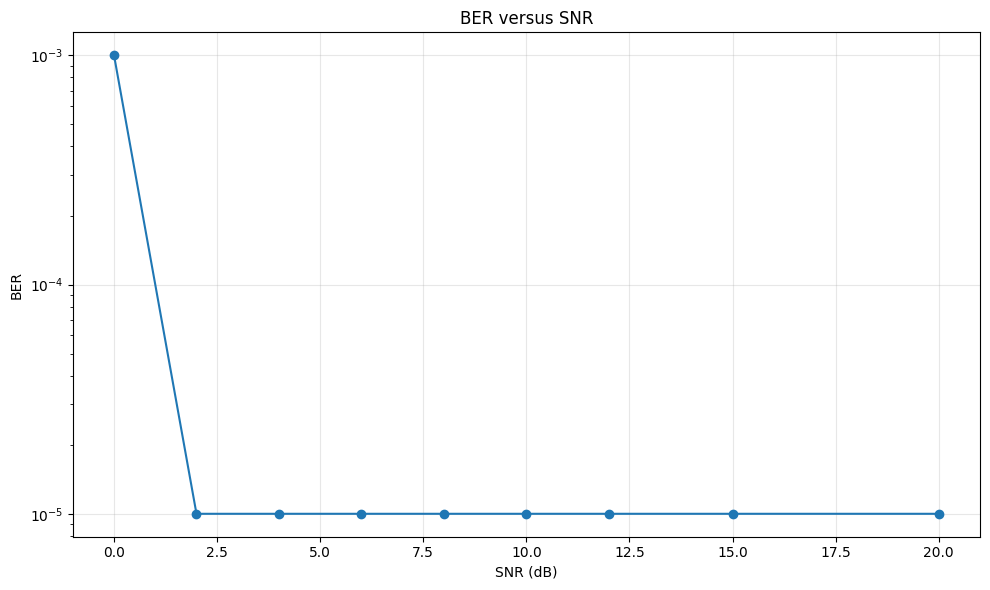


MANDATORY VALIDATION
Single filter delay: 32 samples
Total cascade delay: 64 samples

Symbols are detected only after removing the total cascade delay.

First 10 transmitted symbols:
[-1  1 -1 -1 -1  1 -1 -1 -1  1]

First 10 detected samples:
Symbol 1: -0.7380
Symbol 2: 1.0556
Symbol 3: -1.0579
Symbol 4: -1.1514
Symbol 5: -1.1090
Symbol 6: 0.9614
Symbol 7: -1.0942
Symbol 8: -0.8940
Symbol 9: -1.0881
Symbol 10: 1.0754

EXPERIMENT SUMMARY
Modulation: BPSK
Pulse shaping: Root Raised Cosine
Matched filter: Root Raised Cosine
Samples per symbol: 8
RRC roll-off: 0.35
SNR: 10 dB

Required analyses completed:
1. BPSK transmission through RRC and AWGN
2. Matched RRC filtering
3. Cascade delay compensation
4. Eye diagram
5. Eye height versus SNR
6. BER versus timing offset
7. Multipath ISI channel
8. BER versus SNR
9. Mandatory delay validation

Experiment 8 completed successfully.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 8
# MATCHED FILTERING, ISI AND EYE DIAGRAMS
# ============================================================

np.random.seed(42)

# ============================================================
# PARAMETERS
# ============================================================

num_symbols = 1000
sps = 8                  # samples per symbol
Ts = 1.0
span = 8                 # RRC span in symbols

SNR_dB = 10
rolloff = 0.35

# BPSK symbols
bits = np.random.randint(0, 2, num_symbols)
symbols = 2 * bits - 1


# ============================================================
# RRC FILTER
# ============================================================

def rrc_filter(beta, span, sps):

    N = span * sps
    t = np.arange(-N / 2, N / 2 + 1) / sps

    h = np.zeros_like(t, dtype=float)

    for i, ti in enumerate(t):

        if abs(ti) < 1e-12:
            h[i] = (
                1
                + beta * (4 / np.pi - 1)
            )

        elif beta > 0 and abs(
            abs(ti) - 1 / (4 * beta)
        ) < 1e-10:

            h[i] = (
                beta / np.sqrt(2)
                * (
                    (1 + 2 / np.pi)
                    * np.sin(np.pi / (4 * beta))
                    +
                    (1 - 2 / np.pi)
                    * np.cos(np.pi / (4 * beta))
                )
            )

        else:

            numerator = (
                np.sin(
                    np.pi * ti * (1 - beta)
                )
                +
                4 * beta * ti
                * np.cos(
                    np.pi * ti * (1 + beta)
                )
            )

            denominator = (
                np.pi * ti
                * (
                    1
                    - (4 * beta * ti) ** 2
                )
            )

            h[i] = numerator / denominator

    # Normalize filter energy
    h = h / np.sqrt(np.sum(h ** 2))

    return h


# ============================================================
# UPSAMPLE SYMBOLS
# ============================================================

upsampled = np.zeros(
    num_symbols * sps
)

upsampled[::sps] = symbols


# ============================================================
# TRANSMITTER RRC FILTER
# ============================================================

tx_filter = rrc_filter(
    rolloff,
    span,
    sps
)

tx_signal = np.convolve(
    upsampled,
    tx_filter
)


# ============================================================
# AWGN FUNCTION
# ============================================================

def add_awgn(signal, snr_db):

    signal_power = np.mean(signal ** 2)

    noise_power = (
        signal_power
        / (10 ** (snr_db / 10))
    )

    noise = np.sqrt(
        noise_power
    ) * np.random.randn(
        len(signal)
    )

    return signal + noise


# ============================================================
# AWGN CHANNEL
# ============================================================

rx_noisy = add_awgn(
    tx_signal,
    SNR_dB
)


# ============================================================
# MATCHED FILTER
# ============================================================

rx_filter = tx_filter[::-1]

matched_output = np.convolve(
    rx_noisy,
    rx_filter
)


# ============================================================
# DELAY CALCULATION
# ============================================================

single_filter_delay = (
    len(tx_filter) - 1
) // 2

total_cascade_delay = (
    2 * single_filter_delay
)

print("=" * 60)
print("MATCHED FILTER DELAY")
print("=" * 60)

print(
    "Single RRC filter delay:",
    single_filter_delay,
    "samples"
)

print(
    "Total cascade delay:",
    total_cascade_delay,
    "samples"
)


# ============================================================
# SYMBOL DETECTION AFTER DELAY COMPENSATION
# ============================================================

sample_indices = (
    total_cascade_delay
    + np.arange(num_symbols) * sps
)

# Keep only valid samples
valid = sample_indices < len(matched_output)

sample_indices = sample_indices[valid]

detected_samples = matched_output[
    sample_indices
]

detected_bits = (
    detected_samples >= 0
).astype(int)

original_bits = bits[:len(detected_bits)]


# ============================================================
# BER CALCULATION
# ============================================================

BER = np.mean(
    detected_bits != original_bits
)

print(
    "Detected symbols:",
    len(detected_bits)
)

print(
    "BER at",
    SNR_dB,
    "dB:",
    BER
)


# ============================================================
# 1. TRANSMIT / MATCHED-FILTER OUTPUT
# ============================================================

plot_symbols = 80

plt.figure(figsize=(14, 6))

plt.plot(
    tx_signal[:plot_symbols * sps],
    label="Transmit signal"
)

plt.plot(
    matched_output[
        total_cascade_delay:
        total_cascade_delay
        + plot_symbols * sps
    ],
    label="Matched-filter output"
)

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title(
    "Transmit and Matched-Filter Output"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    "01_transmit_matched_output.png",
    dpi=300
)

plt.show()


# ============================================================
# EYE DIAGRAM FUNCTION
# ============================================================

def plot_eye(
    signal,
    sps,
    title,
    num_traces=100
):

    samples_per_trace = (
        2 * sps
    )

    center = total_cascade_delay

    traces = []

    for k in range(
        1,
        num_traces + 1
    ):

        start = (
            center
            + k * sps
            - sps
        )

        end = (
            start
            + samples_per_trace
        )

        if (
            start >= 0
            and end <= len(signal)
        ):

            traces.append(
                signal[start:end]
            )

    traces = np.array(traces)

    eye_time = np.arange(
        samples_per_trace
    ) / sps - 1

    plt.figure(figsize=(10, 6))

    for trace in traces:
        plt.plot(
            eye_time,
            trace,
            alpha=0.25
        )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "Time / Symbol Period"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(title)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    return traces


# ============================================================
# 2. EYE DIAGRAM
# ============================================================

eye_traces = plot_eye(
    matched_output,
    sps,
    "Eye Diagram after Matched Filtering"
)

plt.savefig(
    "02_eye_diagram.png",
    dpi=300
)

plt.show()


# ============================================================
# 3. EYE HEIGHT VS SNR
# ============================================================

snr_values = [
    0,
    2,
    4,
    6,
    8,
    10,
    12,
    15,
    20
]

eye_heights = []

for snr in snr_values:

    noisy = add_awgn(
        tx_signal,
        snr
    )

    filtered = np.convolve(
        noisy,
        rx_filter
    )

    valid_samples = (
        total_cascade_delay
        + np.arange(num_symbols)
        * sps
    )

    valid_samples = valid_samples[
        valid_samples < len(filtered)
    ]

    samples = filtered[
        valid_samples
    ]

    positive = samples[
        samples > 0
    ]

    negative = samples[
        samples < 0
    ]

    if (
        len(positive) > 0
        and len(negative) > 0
    ):

        eye_height = (
            np.mean(positive)
            - np.mean(negative)
        )

    else:
        eye_height = 0

    eye_heights.append(
        eye_height
    )


plt.figure(figsize=(10, 6))

plt.plot(
    snr_values,
    eye_heights,
    marker="o"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Eye Height")
plt.title("Eye Height versus SNR")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "03_eye_height_vs_snr.png",
    dpi=300
)

plt.show()


# ============================================================
# 4. BER VS TIMING OFFSET
# ============================================================

timing_offsets = np.arange(
    -3,
    4
)

ber_timing = []

filtered_clean = np.convolve(
    tx_signal,
    rx_filter
)

for offset in timing_offsets:

    indices = (
        total_cascade_delay
        + offset
        + np.arange(num_symbols)
        * sps
    )

    valid_indices = (
        (indices >= 0)
        & (indices < len(filtered_clean))
    )

    indices = indices[
        valid_indices
    ]

    samples = filtered_clean[
        indices
    ]

    detected = (
        samples >= 0
    ).astype(int)

    reference = bits[
        :len(detected)
    ]

    ber = np.mean(
        detected != reference
    )

    ber_timing.append(
        ber
    )


plt.figure(figsize=(10, 6))

plt.plot(
    timing_offsets,
    ber_timing,
    marker="o"
)

plt.xlabel(
    "Timing Offset (samples)"
)

plt.ylabel("BER")

plt.title(
    "BER versus Timing Offset"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "04_ber_vs_timing_offset.png",
    dpi=300
)

plt.show()


# ============================================================
# 5. MULTIPATH ISI CHANNEL
# ============================================================

multipath_channel = np.array(
    [1.0, 0.4, 0.2]
)

multipath_signal = np.convolve(
    tx_signal,
    multipath_channel
)

multipath_noisy = add_awgn(
    multipath_signal,
    SNR_dB
)

multipath_output = np.convolve(
    multipath_noisy,
    rx_filter
)

multipath_indices = (
    total_cascade_delay
    + np.arange(num_symbols)
    * sps
)

multipath_indices = (
    multipath_indices[
        multipath_indices
        < len(multipath_output)
    ]
)

multipath_samples = (
    multipath_output[
        multipath_indices
    ]
)

multipath_bits = (
    multipath_samples >= 0
).astype(int)

multipath_reference = bits[
    :len(multipath_bits)
]

multipath_BER = np.mean(
    multipath_bits
    != multipath_reference
)

print("\n" + "=" * 60)
print("MULTIPATH ISI CHANNEL")
print("=" * 60)

print(
    "Multipath channel:",
    multipath_channel
)

print(
    "BER with multipath ISI:",
    multipath_BER
)


# ============================================================
# 6. EYE DIAGRAM WITH MULTIPATH ISI
# ============================================================

eye_multipath = plot_eye(
    multipath_output,
    sps,
    "Eye Diagram with Multipath ISI"
)

plt.savefig(
    "05_eye_diagram_multipath.png",
    dpi=300
)

plt.show()


# ============================================================
# 7. SNR VS BER
# ============================================================

snr_ber_values = [
    0,
    2,
    4,
    6,
    8,
    10,
    12,
    15,
    20
]

ber_values = []

for snr in snr_ber_values:

    noisy = add_awgn(
        tx_signal,
        snr
    )

    filtered = np.convolve(
        noisy,
        rx_filter
    )

    indices = (
        total_cascade_delay
        + np.arange(num_symbols)
        * sps
    )

    indices = indices[
        indices < len(filtered)
    ]

    samples = filtered[
        indices
    ]

    detected = (
        samples >= 0
    ).astype(int)

    reference = bits[
        :len(detected)
    ]

    ber = np.mean(
        detected != reference
    )

    ber_values.append(
        ber
    )


plt.figure(figsize=(10, 6))

plt.semilogy(
    snr_ber_values,
    np.maximum(
        ber_values,
        1e-5
    ),
    marker="o"
)

plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER versus SNR")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "06_ber_vs_snr.png",
    dpi=300
)

plt.show()


# ============================================================
# 8. MANDATORY VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("MANDATORY VALIDATION")
print("=" * 60)

print(
    "Single filter delay:",
    single_filter_delay,
    "samples"
)

print(
    "Total cascade delay:",
    total_cascade_delay,
    "samples"
)

print(
    "\nSymbols are detected only after "
    "removing the total cascade delay."
)

print("\nFirst 10 transmitted symbols:")
print(symbols[:10])

print("\nFirst 10 detected samples:")

for i in range(
    min(10, len(detected_samples))
):

    print(
        f"Symbol {i+1}: "
        f"{detected_samples[i]:.4f}"
    )


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)

print("Modulation: BPSK")
print("Pulse shaping: Root Raised Cosine")
print("Matched filter: Root Raised Cosine")
print("Samples per symbol:", sps)
print("RRC roll-off:", rolloff)
print("SNR:", SNR_dB, "dB")

print("\nRequired analyses completed:")
print("1. BPSK transmission through RRC and AWGN")
print("2. Matched RRC filtering")
print("3. Cascade delay compensation")
print("4. Eye diagram")
print("5. Eye height versus SNR")
print("6. BER versus timing offset")
print("7. Multipath ISI channel")
print("8. BER versus SNR")
print("9. Mandatory delay validation")

print("\nExperiment 8 completed successfully.")